# 🧠 Gen Z Mental Wellness — Burnout Risk Classification
**Dataset:** `genz_mental_wellness_synthetic_dataset.csv`  
**Target:** `Burnout_Risk` (Low / Medium / High)

**Workflow:**
1. Install & Import
2. Load & Inspect Data
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Burnout Risk Analysis by Demographics
7. Correlation Analysis & Heatmap
8. Multi-Model Benchmark (LazyClassifier)
9. Top Models Deep Dive
10. Hyperparameter Tuning
11. Feature Importance
12. Summary

## 0 — Install Dependencies

In [ ]:
%pip install -q lazypredict xgboost lightgbm imbalanced-learn

## 1 — Import Libraries & Load Dataset

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

import xgboost as xgb
import lightgbm as lgb
from lazypredict.Supervised import LazyClassifier

# ── Plotting defaults ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})
RANDOM_STATE = 42
print("All libraries imported ✓")

All libraries imported ✓


In [3]:
DATA_PATH = "genz_mental_wellness_synthetic_dataset.csv"
df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape}")
print(f"\nColumn dtypes:\n{df_raw.dtypes}")
df_raw.head()

Shape: (10000, 22)

Column dtypes:
Age                              int64
Gender                          object
Country                         object
Student_Working_Status          object
Daily_Social_Media_Hours       float64
Screen_Time_Hours              float64
Night_Scrolling_Frequency      float64
Online_Gaming_Hours            float64
Content_Type_Preference         object
Exercise_Frequency_per_Week    float64
Daily_Sleep_Hours              float64
Caffeine_Intake_Cups           float64
Study_Work_Hours_per_Day       float64
Overthinking_Score             float64
Anxiety_Score                  float64
Mood_Stability_Score           float64
Social_Comparison_Index        float64
Sleep_Quality_Score            float64
Motivation_Level               float64
Emotional_Fatigue_Score        float64
Wellbeing_Index                float64
Burnout_Risk                    object
dtype: object


,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,...,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,24,Male,Canada,Working,4.81,6.93,2.61,2.07,News,5.41,...,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,21,Male,USA,Student,4.16,7.94,1.85,3.58,Gaming,3.41,...,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,25,Male,Pakistan,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,...,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,22,Female,Pakistan,Student,4.41,7.34,4.51,3.37,Educational,2.19,...,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,24,Male,Pakistan,Student,2.97,5.76,2.36,1.77,Educational,4.93,...,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium


In [4]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,10000.00,NaN,NaN,NaN,21.99,2.59,18.00,20.00,22.00,24.00,26.00
Gender,10000,3,Male,4547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,10000,6,Pakistan,1804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Student_Working_Status,10000,3,Student,5971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily_Social_Media_Hours,10000.00,NaN,NaN,NaN,4.01,1.48,0.50,3.01,3.99,4.98,10.00
Screen_Time_Hours,10000.00,NaN,NaN,NaN,7.02,1.79,2.00,5.81,7.00,8.21,14.00
Night_Scrolling_Frequency,10000.00,NaN,NaN,NaN,2.99,1.20,0.00,2.19,2.98,3.79,7.00
Online_Gaming_Hours,10000.00,NaN,NaN,NaN,1.61,1.30,0.00,0.47,1.46,2.50,6.00
Content_Type_Preference,10000,5,Gaming,2051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Exercise_Frequency_per_Week,10000.00,NaN,NaN,NaN,2.99,1.48,0.00,1.96,3.01,4.00,7.00


## 2 — Data Cleaning & Preprocessing

In [5]:
df = df_raw.copy()

# ── Missing values ────────────────────────────────────────────────────────────
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "None found ✓")

# ── Duplicates ────────────────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")
if dupes:
    df.drop_duplicates(inplace=True)

# ── Target distribution ───────────────────────────────────────────────────────
print(f"\nTarget value counts:\n{df['Burnout_Risk'].value_counts()}")
print(f"\nClass proportions:\n{df['Burnout_Risk'].value_counts(normalize=True).round(3)}")

=== Missing Values ===
None found ✓

Duplicate rows: 0

Target value counts:
Burnout_Risk
High      5388
Medium    4548
Low         64
Name: count, dtype: int64

Class proportions:
Burnout_Risk
High     0.54
Medium   0.46
Low      0.01
Name: proportion, dtype: float64


## 3 — Exploratory Data Analysis (EDA)

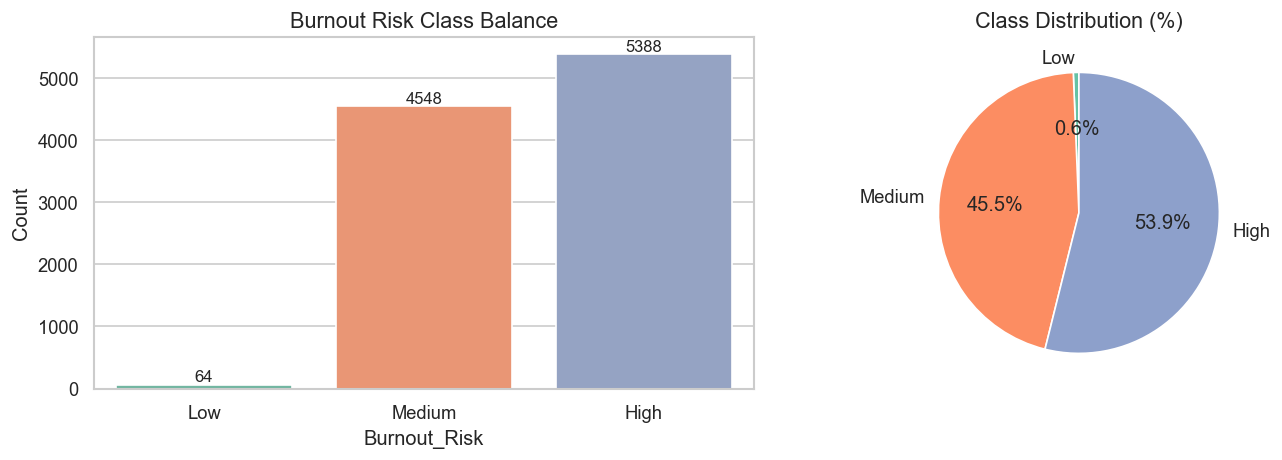

In [6]:
# ── (3.1) Target class balance ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = ["Low", "Medium", "High"]
ax = axes[0]
counts = df["Burnout_Risk"].value_counts()[order]
sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=ax)
ax.set_title("Burnout Risk Class Balance")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2", 3), startangle=90)
axes[1].set_title("Class Distribution (%)")
plt.tight_layout()
plt.show()

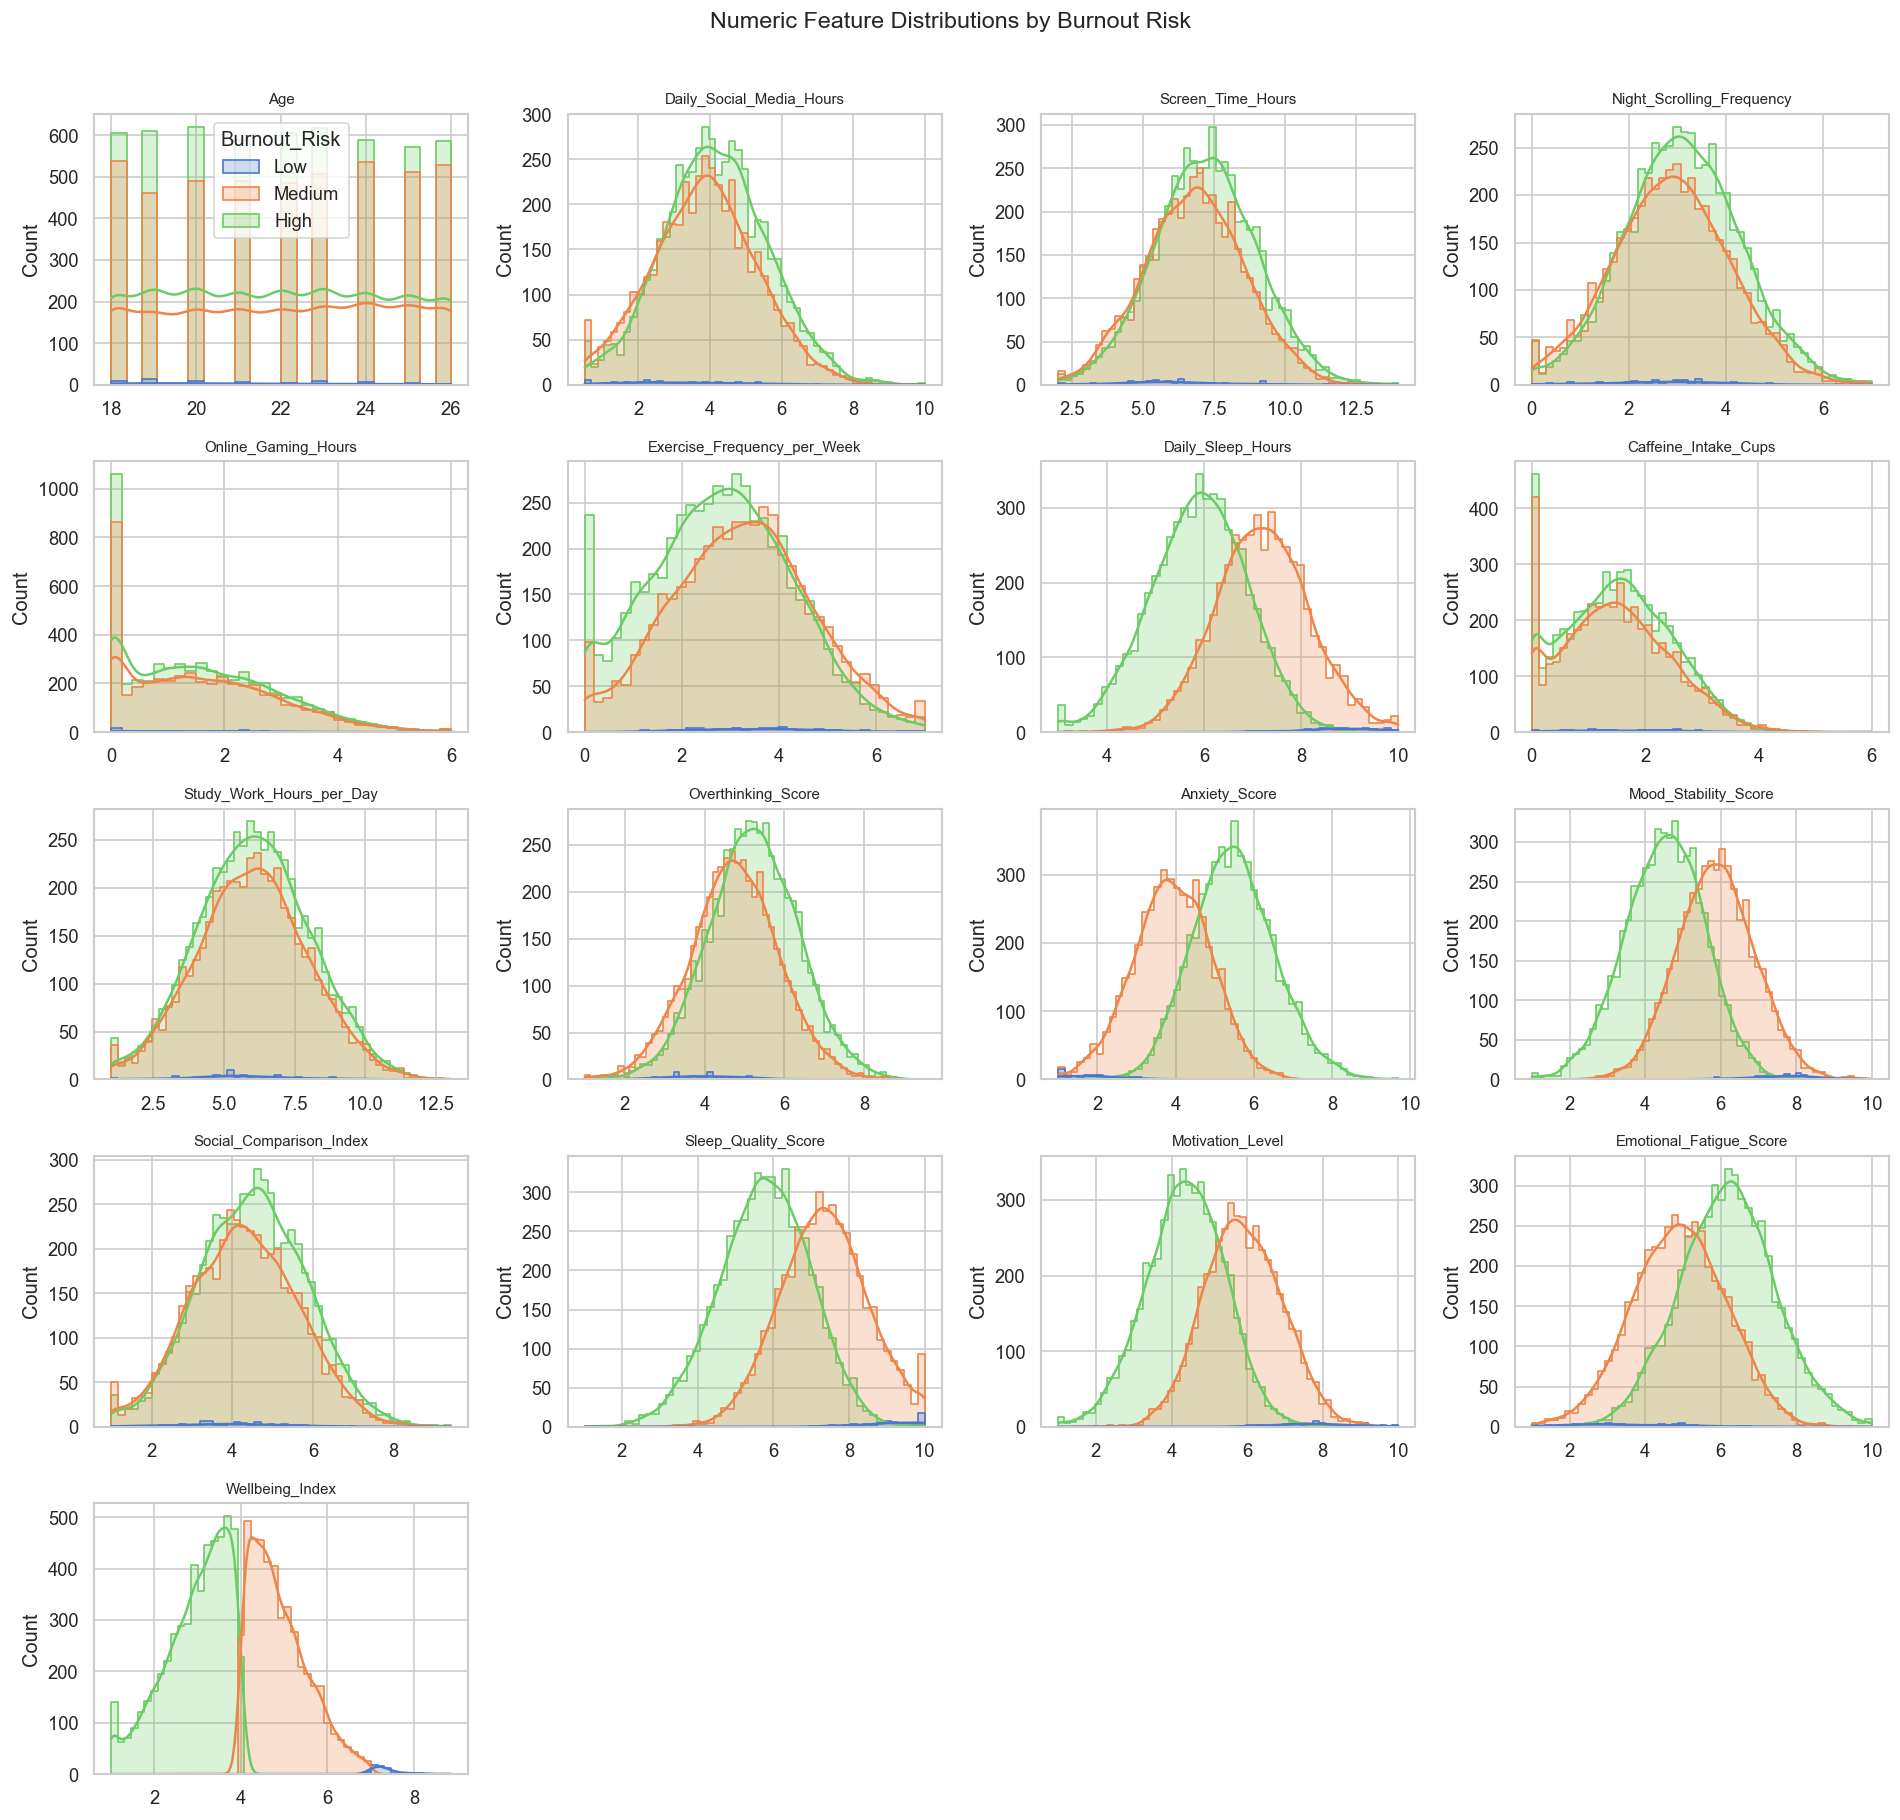

In [7]:
# ── (3.2) Numeric feature distributions ──────────────────────────────────────
num_cols = df.select_dtypes(include="number").columns.tolist()
n = len(num_cols)
cols_per_row = 4
rows = -(-n // cols_per_row)  # ceiling division

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="Burnout_Risk", kde=True,
                 element="step", ax=axes[i], legend=(i == 0),
                 hue_order=["Low", "Medium", "High"])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Numeric Feature Distributions by Burnout Risk", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

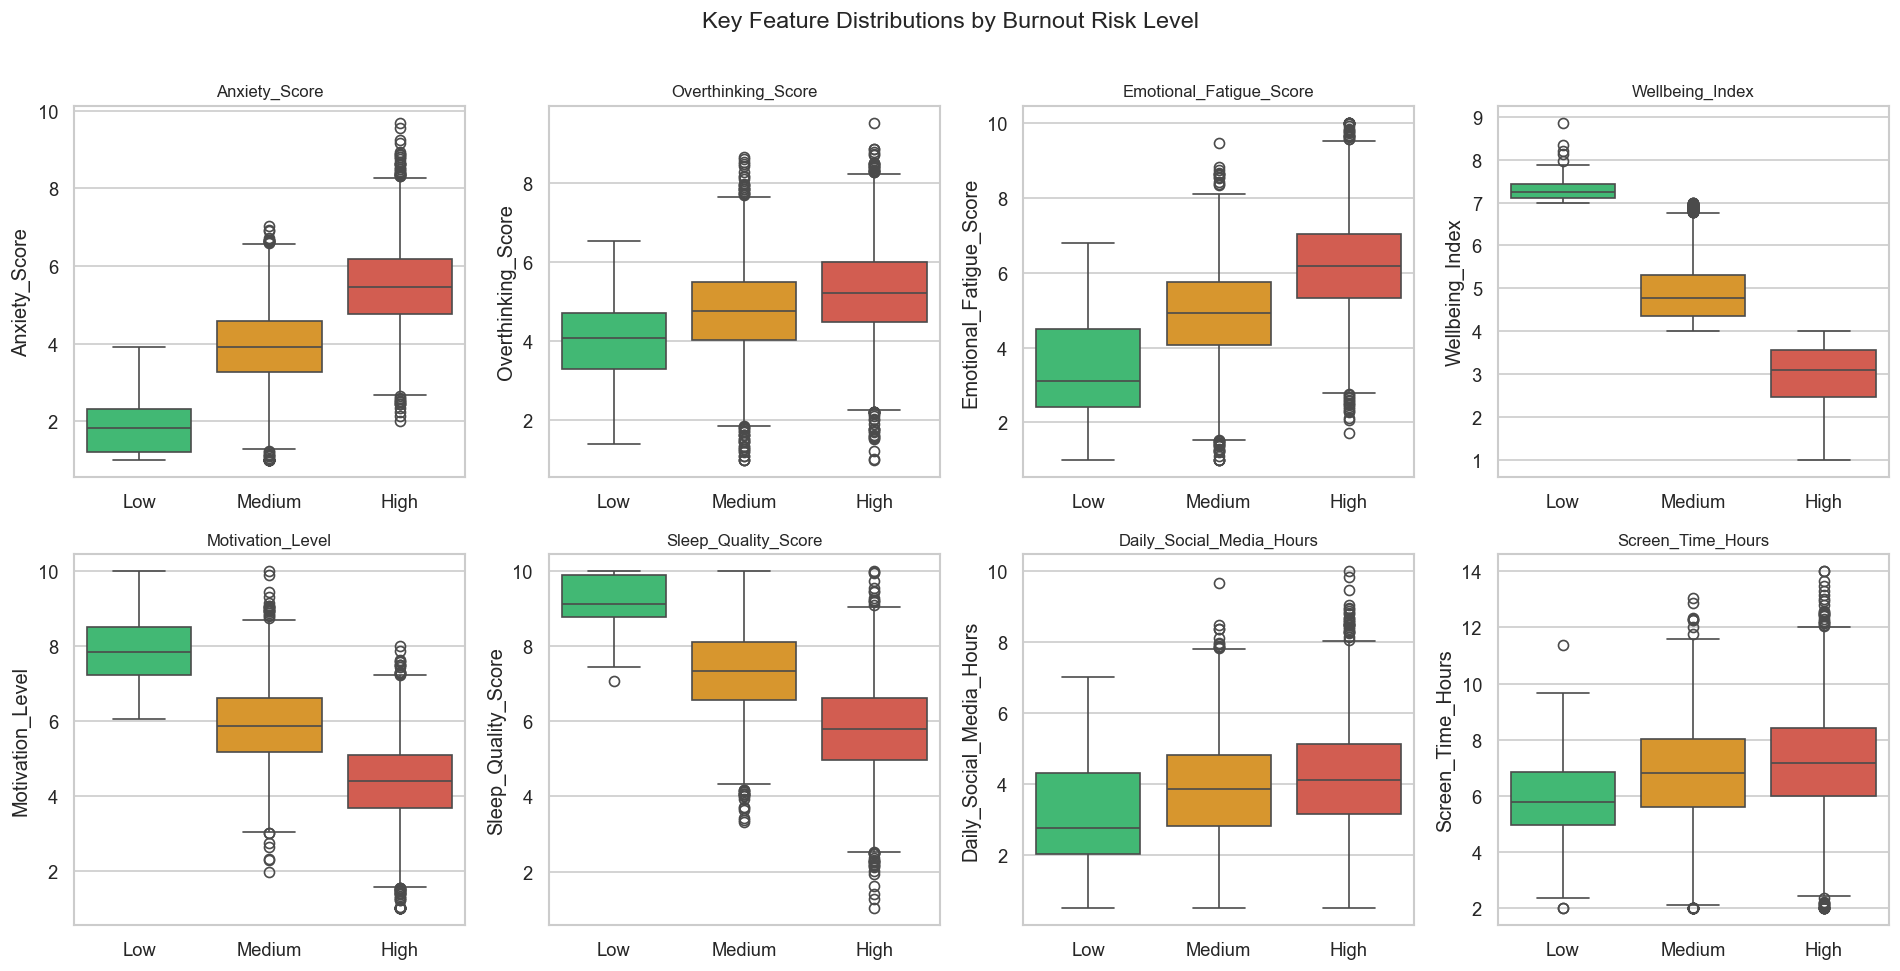

In [8]:
# ── (3.3) Key features boxplots vs Burnout_Risk ───────────────────────────────
key_features = ["Anxiety_Score", "Overthinking_Score", "Emotional_Fatigue_Score",
                "Wellbeing_Index", "Motivation_Level", "Sleep_Quality_Score",
                "Daily_Social_Media_Hours", "Screen_Time_Hours"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}
for i, col in enumerate(key_features):
    sns.boxplot(data=df, x="Burnout_Risk", y=col, order=["Low", "Medium", "High"],
                palette=palette, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
plt.suptitle("Key Feature Distributions by Burnout Risk Level", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

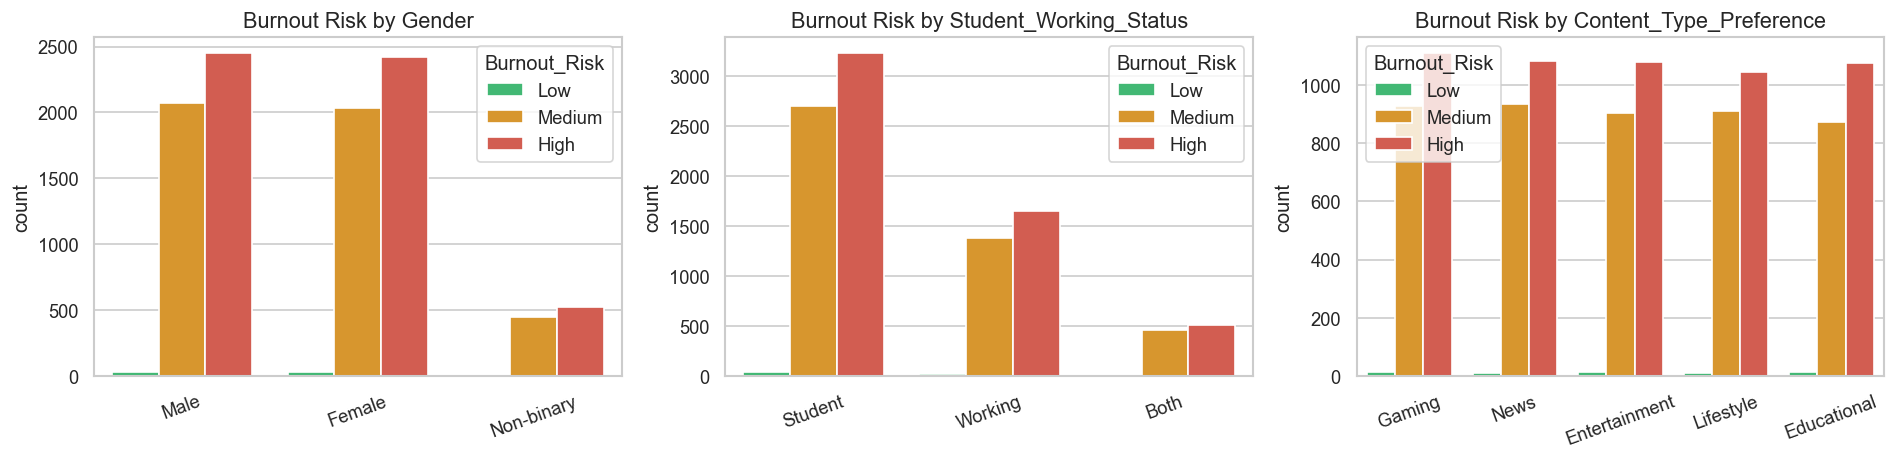

In [9]:
# ── (3.4) Categorical feature counts ─────────────────────────────────────────
cat_cols = ["Gender", "Student_Working_Status", "Content_Type_Preference"]
fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    order_vals = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue="Burnout_Risk",
                  order=order_vals, hue_order=["Low", "Medium", "High"],
                  palette=palette, ax=ax)
    ax.set_title(f"Burnout Risk by {col}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 4 — Feature Engineering

In [10]:
df_fe = df.copy()

# ── Composite stress index ────────────────────────────────────────────────────
df_fe["Stress_Load"] = (df_fe["Anxiety_Score"]
                       + df_fe["Overthinking_Score"]
                       + df_fe["Emotional_Fatigue_Score"])

# ── Sleep deficit (how many hours short of 8h) ────────────────────────────────
df_fe["Sleep_Deficit"] = (8 - df_fe["Daily_Sleep_Hours"]).clip(lower=0)

# ── Screen-to-sleep ratio ─────────────────────────────────────────────────────
df_fe["Screen_Sleep_Ratio"] = df_fe["Screen_Time_Hours"] / (df_fe["Daily_Sleep_Hours"] + 1)

# ── Total digital exposure ────────────────────────────────────────────────────
df_fe["Social_Digital_Load"] = (df_fe["Daily_Social_Media_Hours"]
                                + df_fe["Night_Scrolling_Frequency"])

# ── Healthy habits score ──────────────────────────────────────────────────────
df_fe["Healthy_Habits"] = df_fe["Exercise_Frequency_per_Week"] * df_fe["Mood_Stability_Score"]

# ── Age group (binned) ────────────────────────────────────────────────────────
df_fe["Age_Group"] = pd.cut(df_fe["Age"], bins=[0, 19, 22, 26, 100],
                             labels=["<20", "20-22", "23-26", "27+"])

new_features = ["Stress_Load", "Sleep_Deficit", "Screen_Sleep_Ratio",
                "Social_Digital_Load", "Healthy_Habits"]
print("New feature summary:")
df_fe[new_features].describe().T.round(2)

New feature summary:


,count,mean,std,min,25%,50%,75%,max
Stress_Load,10000.00,15.33,3.02,4.20,13.31,15.30,17.38,26.08
Sleep_Deficit,10000.00,1.55,1.09,0.00,0.68,1.48,2.29,5.00
Screen_Sleep_Ratio,10000.00,0.96,0.30,0.19,0.75,0.94,1.14,2.92
Social_Digital_Load,10000.00,6.99,1.90,0.91,5.72,6.99,8.25,13.77
Healthy_Habits,10000.00,15.47,8.71,0.00,9.14,14.73,20.96,58.45


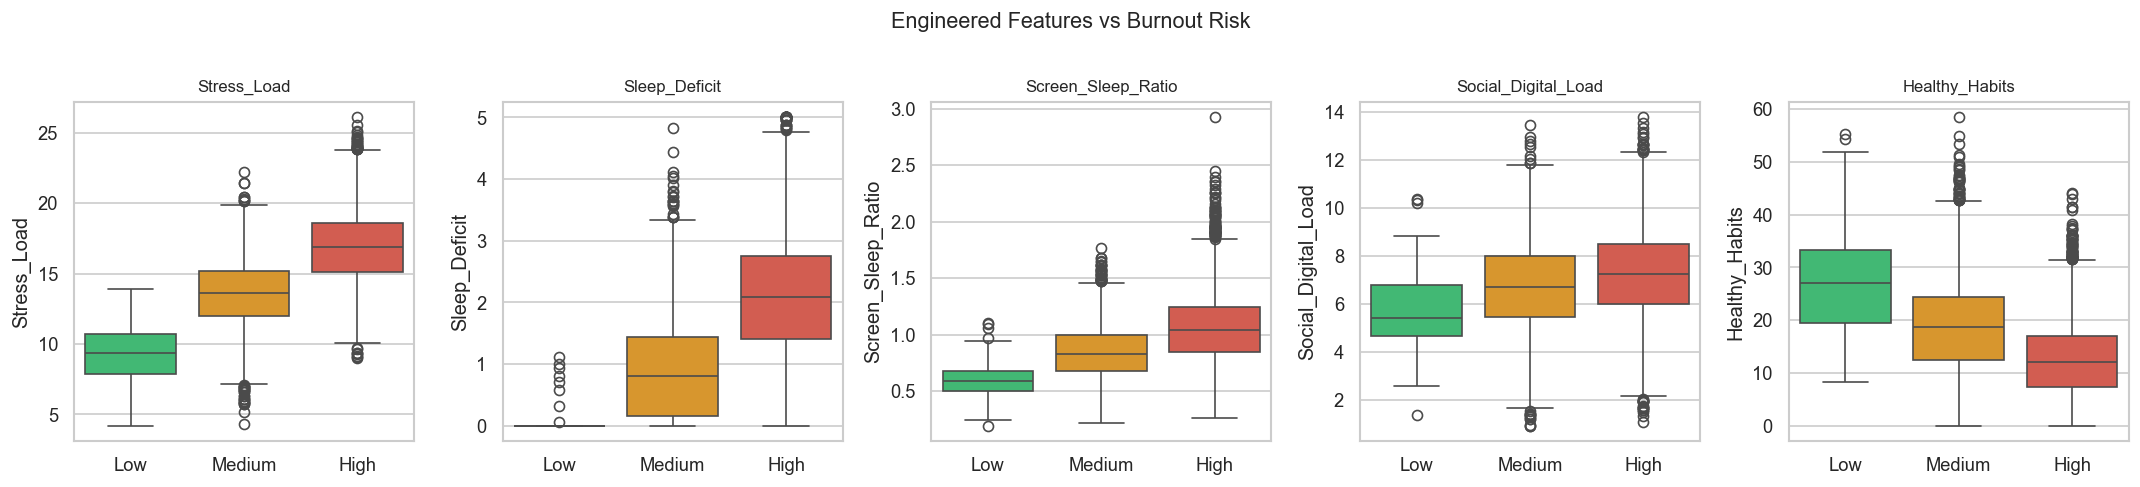

In [11]:
# ── Visualise engineered features vs Burnout_Risk ────────────────────────────
fig, axes = plt.subplots(1, len(new_features), figsize=(18, 4))
for ax, col in zip(axes, new_features):
    sns.boxplot(data=df_fe, x="Burnout_Risk", y=col,
                order=["Low", "Medium", "High"], palette=palette, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Engineered Features vs Burnout Risk", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5 — Burnout Risk Analysis by Demographics

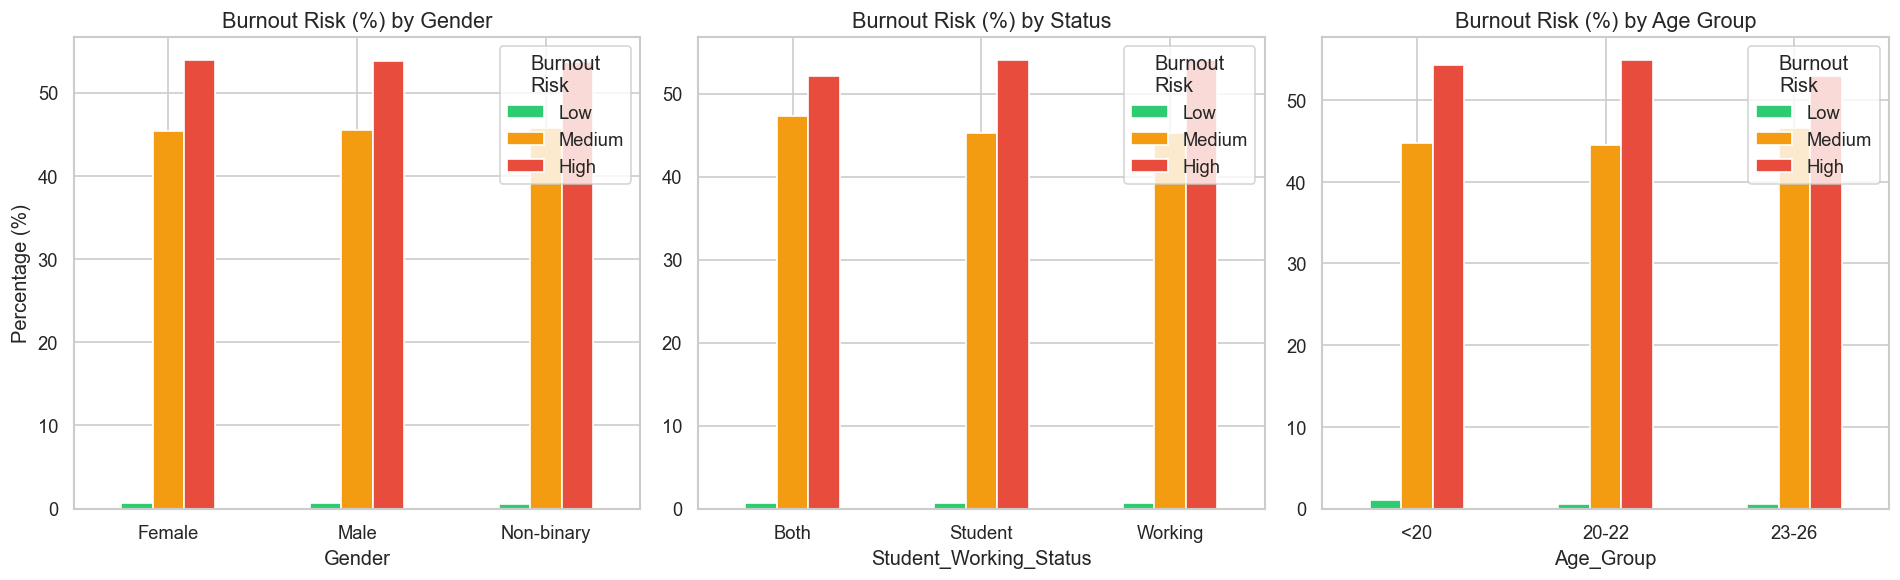

In [12]:
# ── (5.1) Gender × Burnout Risk ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender
ct_gender = pd.crosstab(df_fe["Gender"], df_fe["Burnout_Risk"],
                         normalize="index")[["Low", "Medium", "High"]] * 100
ct_gender.plot(kind="bar", ax=axes[0], color=["#2ecc71", "#f39c12", "#e74c3c"],
               rot=0, edgecolor="white")
axes[0].set_title("Burnout Risk (%) by Gender")
axes[0].set_ylabel("Percentage (%)")
axes[0].legend(title="Burnout\nRisk")

# Student / Working status
ct_sw = pd.crosstab(df_fe["Student_Working_Status"], df_fe["Burnout_Risk"],
                    normalize="index")[["Low", "Medium", "High"]] * 100
ct_sw.plot(kind="bar", ax=axes[1], color=["#2ecc71", "#f39c12", "#e74c3c"],
           rot=0, edgecolor="white")
axes[1].set_title("Burnout Risk (%) by Status")
axes[1].set_ylabel("")
axes[1].legend(title="Burnout\nRisk")

# Age group
ct_age = pd.crosstab(df_fe["Age_Group"], df_fe["Burnout_Risk"],
                     normalize="index")[["Low", "Medium", "High"]] * 100
ct_age.plot(kind="bar", ax=axes[2], color=["#2ecc71", "#f39c12", "#e74c3c"],
            rot=0, edgecolor="white")
axes[2].set_title("Burnout Risk (%) by Age Group")
axes[2].set_ylabel("")
axes[2].legend(title="Burnout\nRisk")

plt.tight_layout()
plt.show()

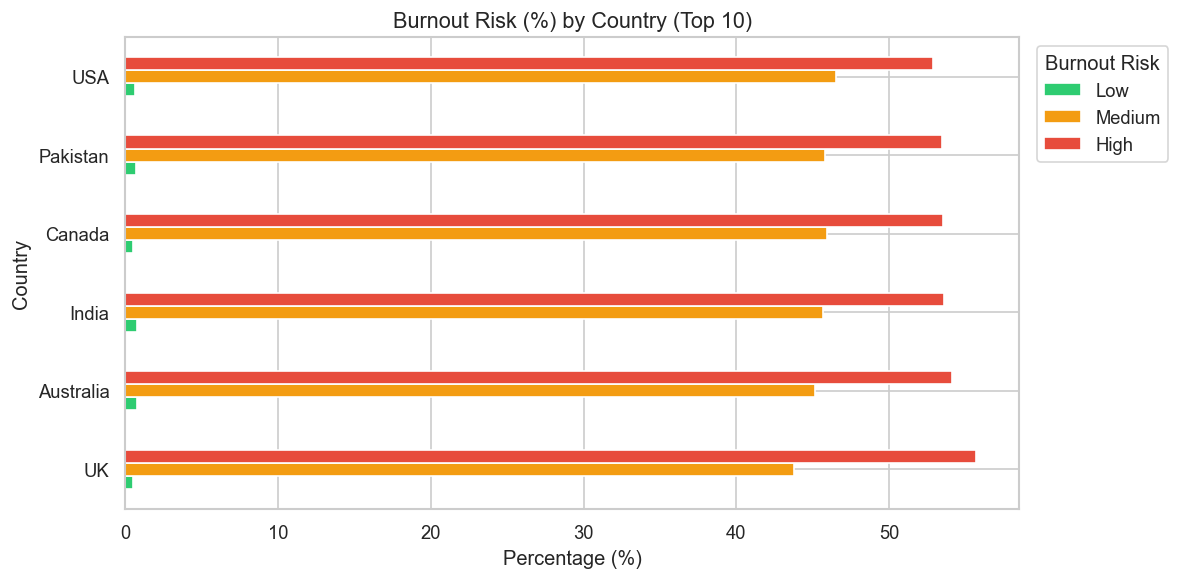

In [13]:
# ── (5.2) Top countries ───────────────────────────────────────────────────────
top_countries = df_fe["Country"].value_counts().head(10).index
df_top = df_fe[df_fe["Country"].isin(top_countries)]

ct_country = pd.crosstab(df_top["Country"], df_top["Burnout_Risk"],
                          normalize="index")[["Low", "Medium", "High"]] * 100
ct_country = ct_country.loc[ct_country["High"].sort_values(ascending=False).index]

ax = ct_country.plot(kind="barh", figsize=(10, 5),
                     color=["#2ecc71", "#f39c12", "#e74c3c"], edgecolor="white")
ax.set_title("Burnout Risk (%) by Country (Top 10)")
ax.set_xlabel("Percentage (%)")
ax.legend(title="Burnout Risk", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## 6 — Correlation Analysis & Heatmap

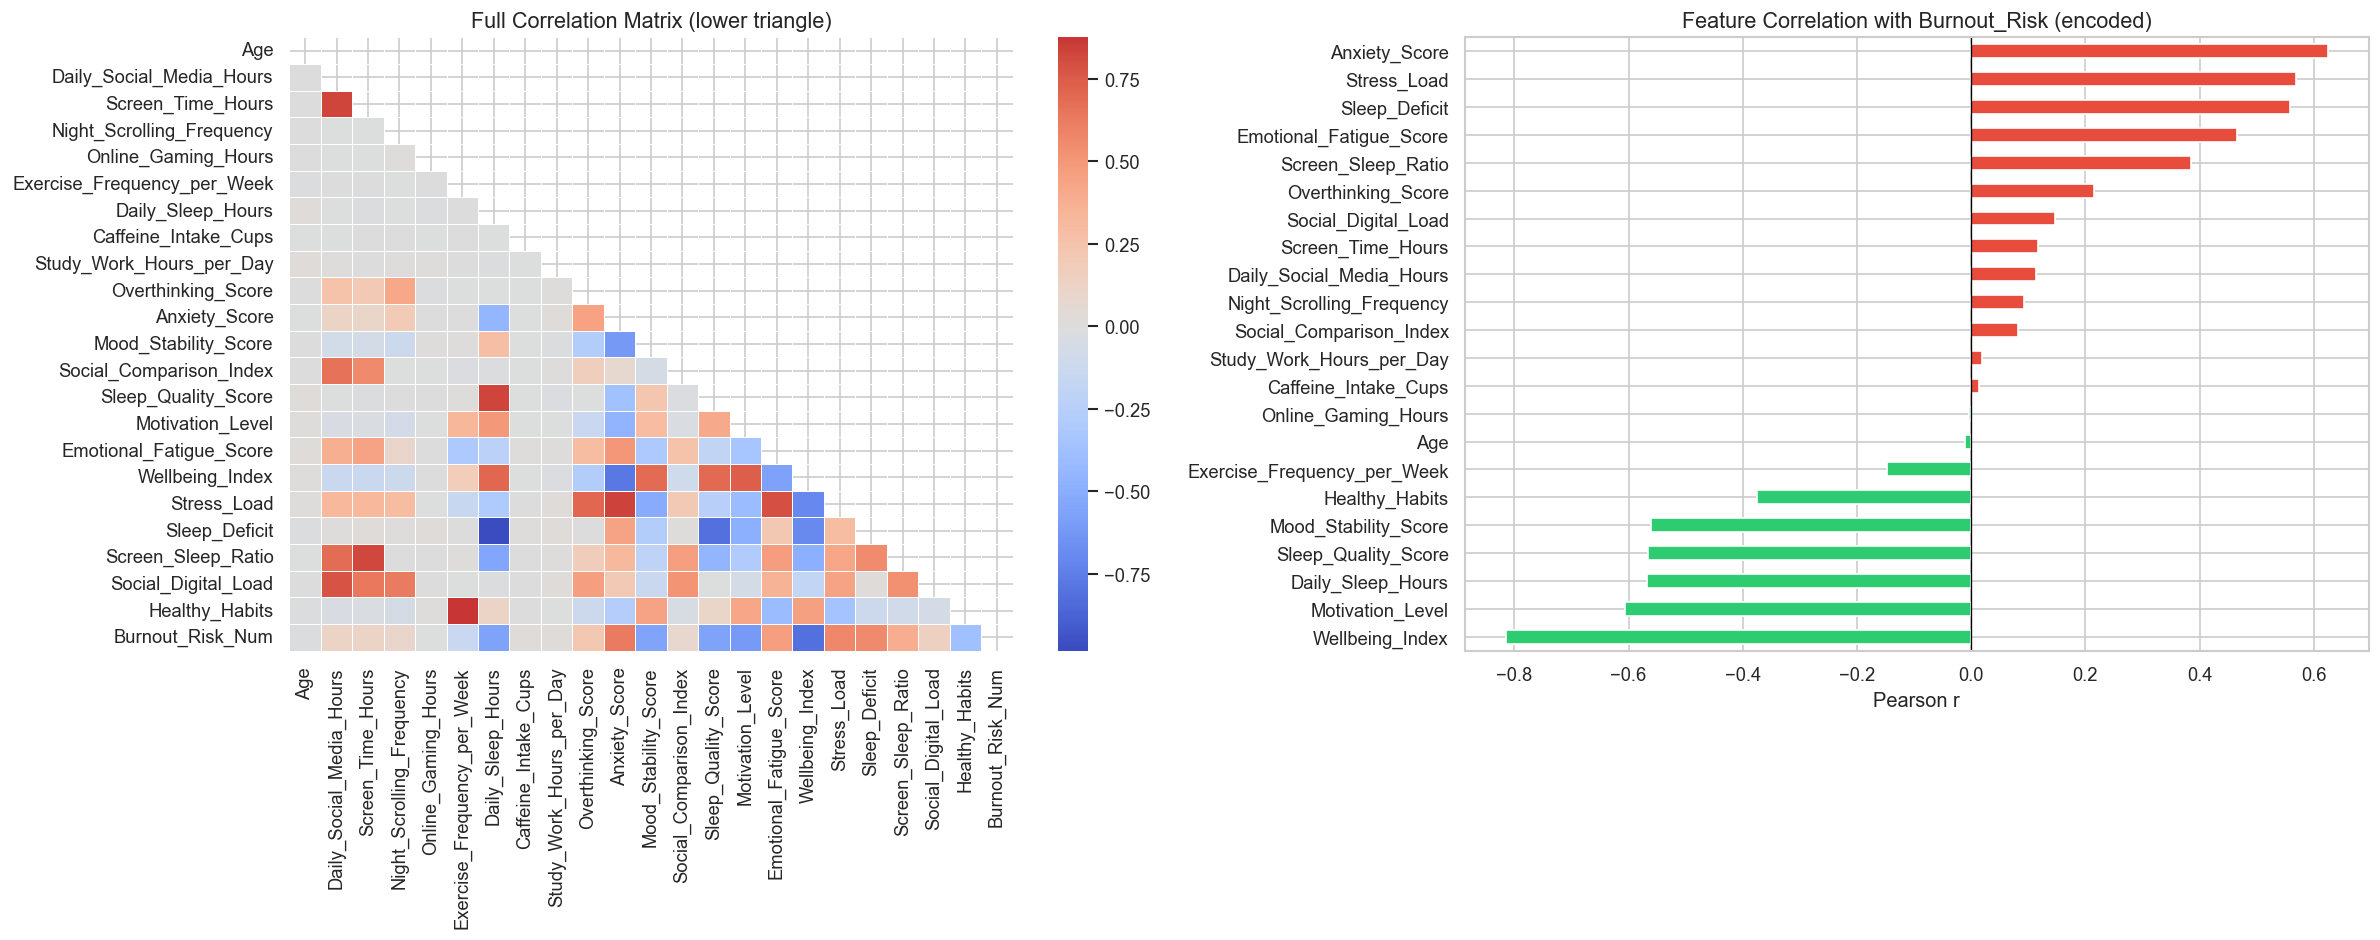

In [14]:
# Encode target numerically for correlation
df_corr = df_fe.copy()
risk_map = {"Low": 0, "Medium": 1, "High": 2}
df_corr["Burnout_Risk_Num"] = df_corr["Burnout_Risk"].map(risk_map)

num_fe_cols = df_corr.select_dtypes(include="number").columns.tolist()
corr_matrix = df_corr[num_fe_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, ax=axes[0])
axes[0].set_title("Full Correlation Matrix (lower triangle)", fontsize=13)

# Top correlations with target
target_corr = corr_matrix["Burnout_Risk_Num"].drop("Burnout_Risk_Num").sort_values()
colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in target_corr]
target_corr.plot(kind="barh", color=colors, ax=axes[1])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Feature Correlation with Burnout_Risk (encoded)", fontsize=13)
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

## 7 — Encode & Prepare Data for Modeling

In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder

df_model = df_fe.copy()

# ── Encode target ─────────────────────────────────────────────────────────────
le_target = LabelEncoder()
df_model["target"] = le_target.fit_transform(df_model["Burnout_Risk"])  # High=0, Low=1, Medium=2
print("Target classes:", le_target.classes_)

# ── Drop original target + Age_Group (already split into numeric bins) ──────
df_model.drop(columns=["Burnout_Risk", "Age_Group"], inplace=True)

# ── Identify feature types ────────────────────────────────────────────────────
CAT_COLS = ["Gender", "Country", "Student_Working_Status", "Content_Type_Preference"]
NUM_COLS = [c for c in df_model.columns if c not in CAT_COLS + ["target"]]

print(f"\nNumeric features ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nCategorical features ({len(CAT_COLS)}): {CAT_COLS}")

X = df_model.drop(columns=["target"])
y = df_model["target"]

# ── Preprocessing pipeline ────────────────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
])

# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Pre-fit transformed arrays for LazyClassifier
X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

print(f"\nTrain size : {X_train.shape[0]}")
print(f"Test  size : {X_test.shape[0]}")
print(f"Transformed feature count: {X_train_t.shape[1]}")

Target classes: ['High' 'Low' 'Medium']

Numeric features (22): ['Age', 'Daily_Social_Media_Hours', 'Screen_Time_Hours', 'Night_Scrolling_Frequency', 'Online_Gaming_Hours', 'Exercise_Frequency_per_Week', 'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day', 'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score', 'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level', 'Emotional_Fatigue_Score', 'Wellbeing_Index', 'Stress_Load', 'Sleep_Deficit', 'Screen_Sleep_Ratio', 'Social_Digital_Load', 'Healthy_Habits']

Categorical features (4): ['Gender', 'Country', 'Student_Working_Status', 'Content_Type_Preference']

Train size : 8000
Test  size : 2000
Transformed feature count: 39


## 8 — Multi-Model Benchmark (LazyClassifier)

In [16]:
lazy_clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None,
                          predictions=False)
lazy_models, lazy_preds = lazy_clf.fit(X_train_t, X_test_t, y_train, y_test)

print("=== LazyClassifier Leaderboard ===")
lazy_models_sorted = lazy_models.sort_values("F1 Score", ascending=False)
display(lazy_models_sorted)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001894 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5414
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 39
[LightGBM] [Info] Start training from score -0.618504
[LightGBM] [Info] Start training from score -5.055371
[LightGBM] [Info] Start training from score -0.787733
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
BaggingClassifier,1.00,0.97,None,1.00,0.28
AdaBoostClassifier,1.00,0.97,None,1.00,1.08
DecisionTreeClassifier,1.00,0.97,None,1.00,0.07
RandomForestClassifier,1.00,0.95,None,1.00,1.52
LGBMClassifier,0.99,0.89,None,0.99,0.33
XGBClassifier,0.99,0.87,None,0.99,0.62
LogisticRegression,0.99,0.87,None,0.99,0.14
LinearSVC,0.99,0.66,None,0.99,0.12
CalibratedClassifierCV,0.99,0.66,None,0.98,0.50


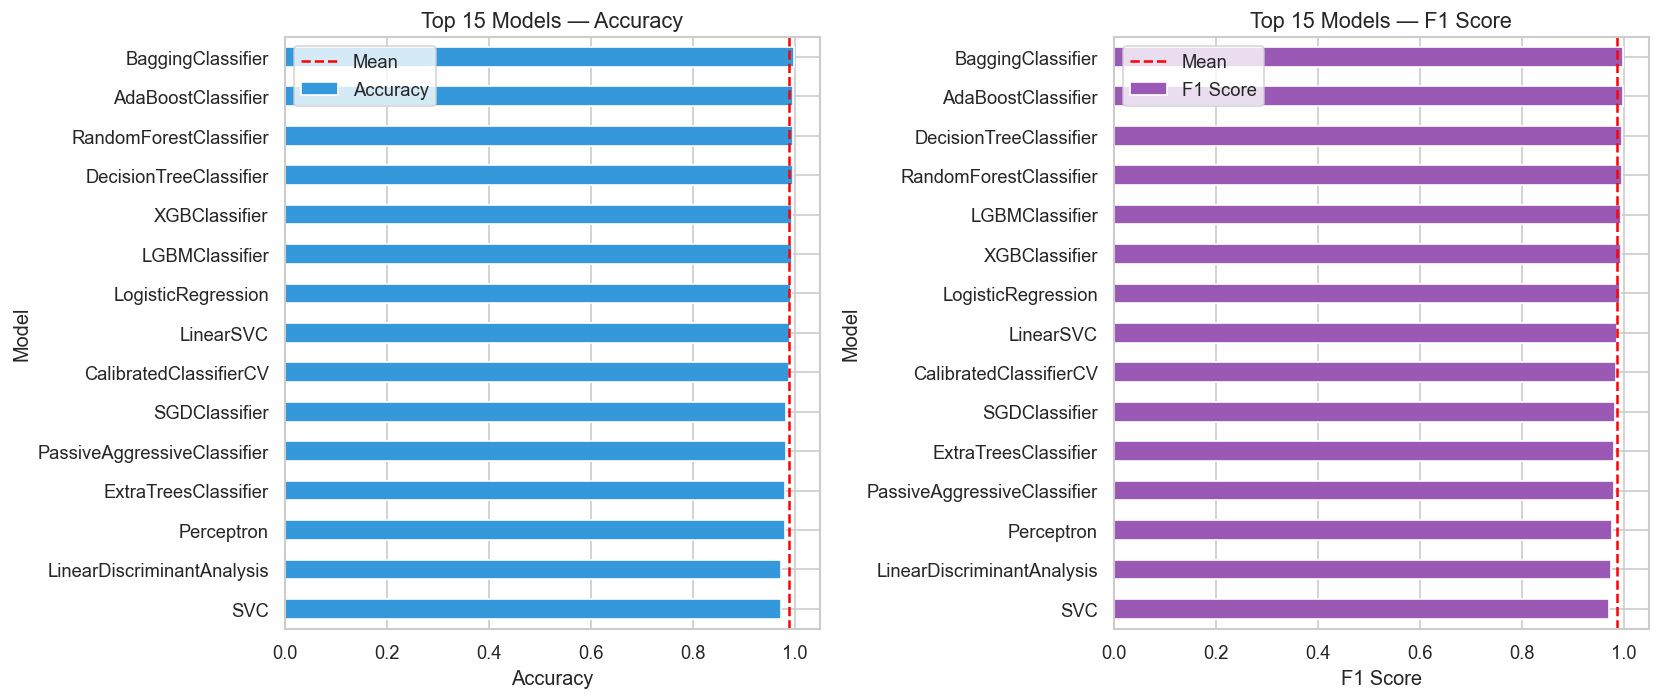


Top-3 candidates: ['BaggingClassifier', 'AdaBoostClassifier', 'DecisionTreeClassifier']


In [17]:
# ── Leaderboard bar chart ─────────────────────────────────────────────────────
top_n = min(15, len(lazy_models_sorted))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy
top_acc = lazy_models_sorted["Accuracy"].head(top_n).sort_values()
top_acc.plot(kind="barh", ax=axes[0], color="#3498db", edgecolor="white")
axes[0].set_title(f"Top {top_n} Models — Accuracy")
axes[0].set_xlabel("Accuracy")
axes[0].axvline(top_acc.mean(), color="red", linestyle="--", label="Mean")
axes[0].legend()

# F1
top_f1 = lazy_models_sorted["F1 Score"].head(top_n).sort_values()
top_f1.plot(kind="barh", ax=axes[1], color="#9b59b6", edgecolor="white")
axes[1].set_title(f"Top {top_n} Models — F1 Score")
axes[1].set_xlabel("F1 Score")
axes[1].axvline(top_f1.mean(), color="red", linestyle="--", label="Mean")
axes[1].legend()

plt.tight_layout()
plt.show()

TOP_3 = lazy_models_sorted.index[:3].tolist()
print(f"\nTop-3 candidates: {TOP_3}")

## 9 — Top Models Deep Dive

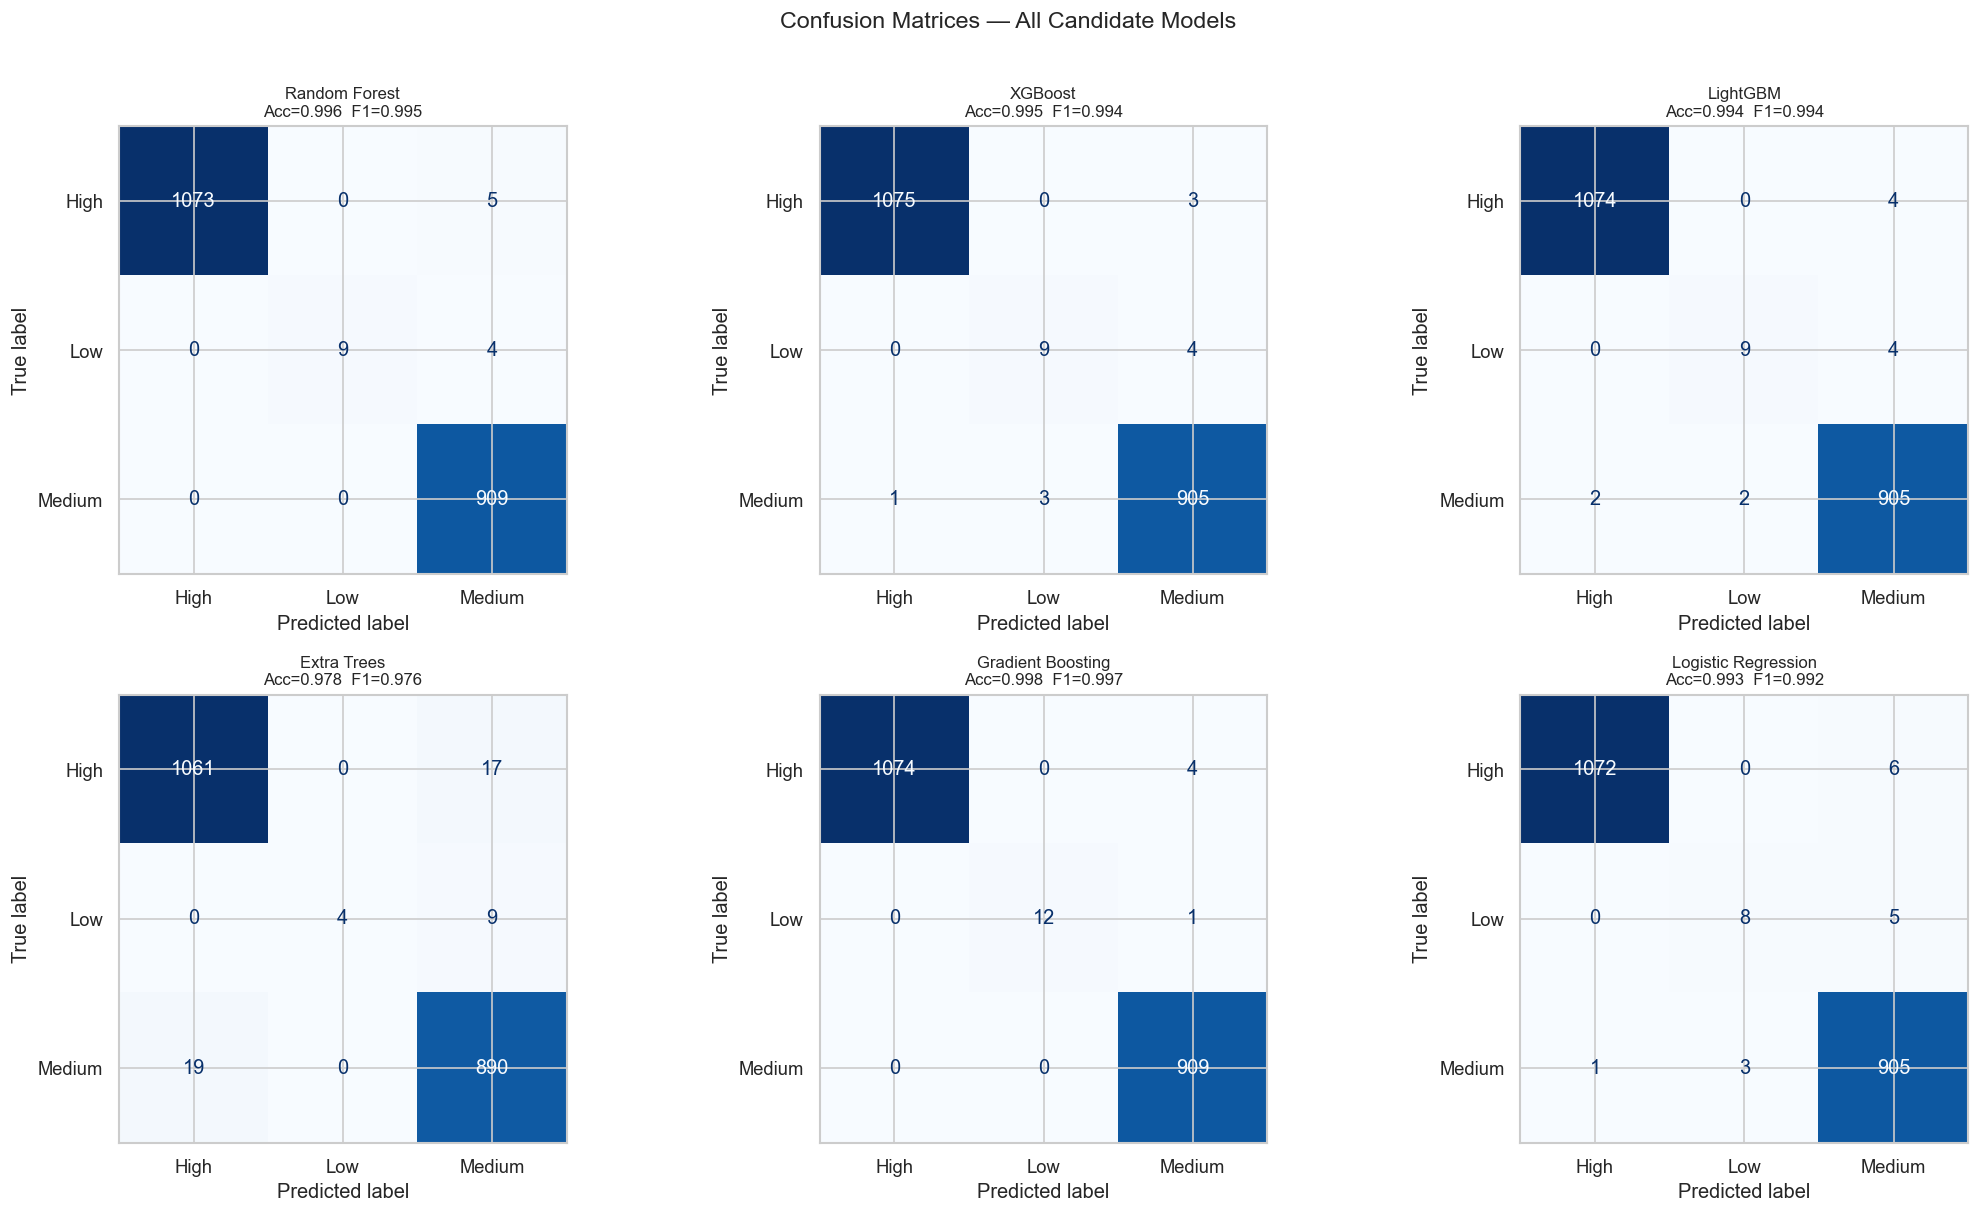

In [18]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb

target_names = le_target.classes_  # ['High', 'Low', 'Medium']

# ── Define candidate models ────────────────────────────────────────────────────
# NOTE: Edit this dict to match your actual Top-3 from Section 8 if different
candidate_models = {
    "Random Forest":          RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "XGBoost":                xgb.XGBClassifier(n_estimators=200, use_label_encoder=False,
                                                 eval_metric="mlogloss", random_state=RANDOM_STATE),
    "LightGBM":               lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1),
    "Extra Trees":            ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting":      GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Logistic Regression":    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(candidate_models.items()):
    model.fit(X_train_t, y_train)
    y_pred = model.predict(X_test_t)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")
    results[name] = {"Accuracy": acc, "F1 (weighted)": f1}

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot(ax=axes[idx], colorbar=False, cmap="Blues")
    axes[idx].set_title(f"{name}\nAcc={acc:.3f}  F1={f1:.3f}", fontsize=10)

plt.suptitle("Confusion Matrices — All Candidate Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# ── Detailed classification reports ──────────────────────────────────────────
for name, model in candidate_models.items():
    y_pred = model.predict(X_test_t)
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=target_names))


  Random Forest
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1078
         Low       1.00      0.69      0.82        13
      Medium       0.99      1.00      1.00       909

    accuracy                           1.00      2000
   macro avg       1.00      0.90      0.94      2000
weighted avg       1.00      1.00      1.00      2000


  XGBoost
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1078
         Low       0.75      0.69      0.72        13
      Medium       0.99      1.00      0.99       909

    accuracy                           0.99      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.99      0.99      0.99      2000


  LightGBM
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1078
         Low       0.82      0.69      0.75        13
      Medium       0.99      1.00  

                     Accuracy  F1 (weighted)
Gradient Boosting        1.00           1.00
Random Forest            1.00           1.00
XGBoost                  0.99           0.99
LightGBM                 0.99           0.99
Logistic Regression      0.99           0.99
Extra Trees              0.98           0.98


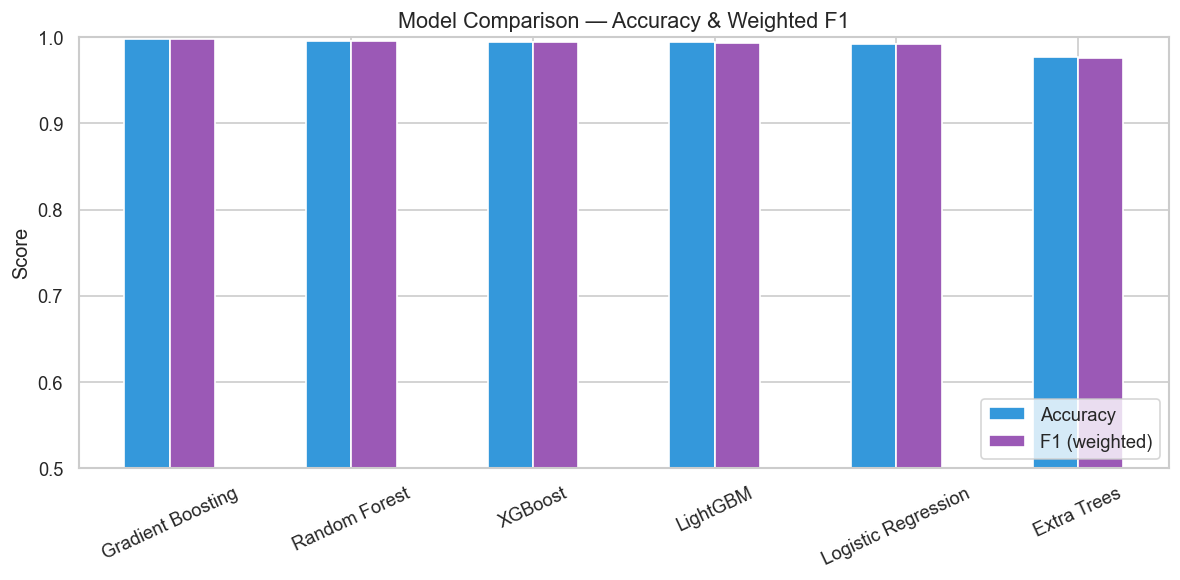


🏆 Best model: Gradient Boosting


In [20]:
# ── Results comparison bar chart ──────────────────────────────────────────────
results_df = pd.DataFrame(results).T.sort_values("F1 (weighted)", ascending=False)
print(results_df.round(4))

ax = results_df.plot(kind="bar", figsize=(10, 5), edgecolor="white",
                     color=["#3498db", "#9b59b6"])
ax.set_title("Model Comparison — Accuracy & Weighted F1", fontsize=13)
ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.0)
ax.legend(loc="lower right")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

BEST_MODEL_NAME = results_df.index[0]
print(f"\n🏆 Best model: {BEST_MODEL_NAME}")

## 10 — Hyperparameter Tuning (RandomizedSearchCV on Best Model)

In [21]:
# ── Param grids for common top models ─────────────────────────────────────────
param_grids = {
    "Random Forest": {
        "n_estimators":      [100, 200, 400],
        "max_depth":         [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf":  [1, 2, 4],
        "max_features":      ["sqrt", "log2"],
    },
    "XGBoost": {
        "n_estimators":    [100, 200, 400],
        "max_depth":       [3, 5, 7, 10],
        "learning_rate":   [0.01, 0.05, 0.1, 0.2],
        "subsample":       [0.7, 0.8, 1.0],
        "colsample_bytree":[0.7, 0.8, 1.0],
        "gamma":           [0, 0.1, 0.3],
    },
    "LightGBM": {
        "n_estimators":   [100, 200, 400],
        "max_depth":      [-1, 5, 10, 20],
        "learning_rate":  [0.01, 0.05, 0.1, 0.2],
        "num_leaves":     [31, 63, 127],
        "subsample":      [0.7, 0.8, 1.0],
    },
    "Extra Trees": {
        "n_estimators":      [100, 200, 400],
        "max_depth":         [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "max_features":      ["sqrt", "log2"],
    },
    "Gradient Boosting": {
        "n_estimators":  [100, 200],
        "max_depth":     [3, 5, 7],
        "learning_rate": [0.05, 0.1, 0.2],
        "subsample":     [0.8, 1.0],
        "max_features":  ["sqrt", "log2"],
    },
}

# Fall back to Random Forest if best model not in param_grids
tune_name = BEST_MODEL_NAME if BEST_MODEL_NAME in param_grids else "Random Forest"
tune_model_cls = {
    "Random Forest":       RandomForestClassifier,
    "XGBoost":             xgb.XGBClassifier,
    "LightGBM":            lgb.LGBMClassifier,
    "Extra Trees":         ExtraTreesClassifier,
    "Gradient Boosting":   GradientBoostingClassifier,
}[tune_name]

extra_kwargs = {"random_state": RANDOM_STATE}
if tune_name == "XGBoost":
    extra_kwargs.update({"use_label_encoder": False, "eval_metric": "mlogloss"})
if tune_name == "LightGBM":
    extra_kwargs["verbose"] = -1

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    tune_model_cls(**extra_kwargs),
    param_distributions=param_grids[tune_name],
    n_iter=30,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
search.fit(X_train_t, y_train)

print(f"\nBest params for {tune_name}:\n{search.best_params_}")
print(f"Best CV F1 (weighted): {search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params for Gradient Boosting:
{'subsample': 0.8, 'n_estimators': 200, 'max_features': 'log2', 'max_depth': 7, 'learning_rate': 0.1}
Best CV F1 (weighted): 0.9988


Tuned Gradient Boosting — Test Accuracy: 0.9950  |  F1 (weighted): 0.9947

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1078
         Low       1.00      0.62      0.76        13
      Medium       0.99      1.00      0.99       909

    accuracy                           0.99      2000
   macro avg       1.00      0.87      0.92      2000
weighted avg       1.00      0.99      0.99      2000



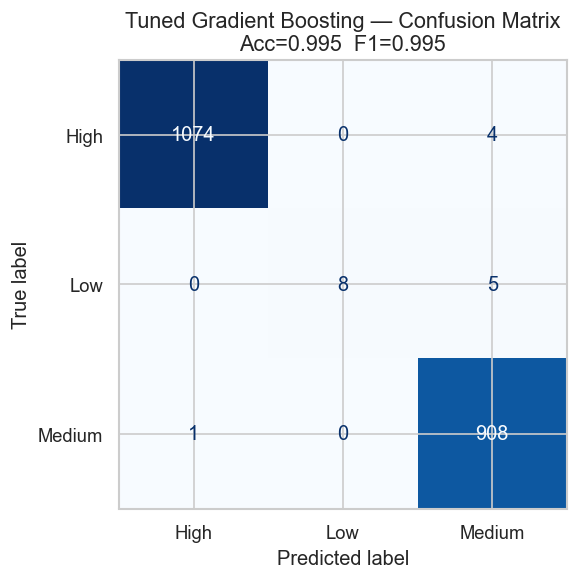

In [22]:
# ── Evaluate tuned model on test set ─────────────────────────────────────────
best_model = search.best_estimator_
y_pred_tuned = best_model.predict(X_test_t)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned  = f1_score(y_test, y_pred_tuned, average="weighted")

print(f"Tuned {tune_name} — Test Accuracy: {acc_tuned:.4f}  |  F1 (weighted): {f1_tuned:.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned, target_names=target_names))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Tuned {tune_name} — Confusion Matrix\nAcc={acc_tuned:.3f}  F1={f1_tuned:.3f}")
plt.tight_layout()
plt.show()

## 11 — Feature Importance

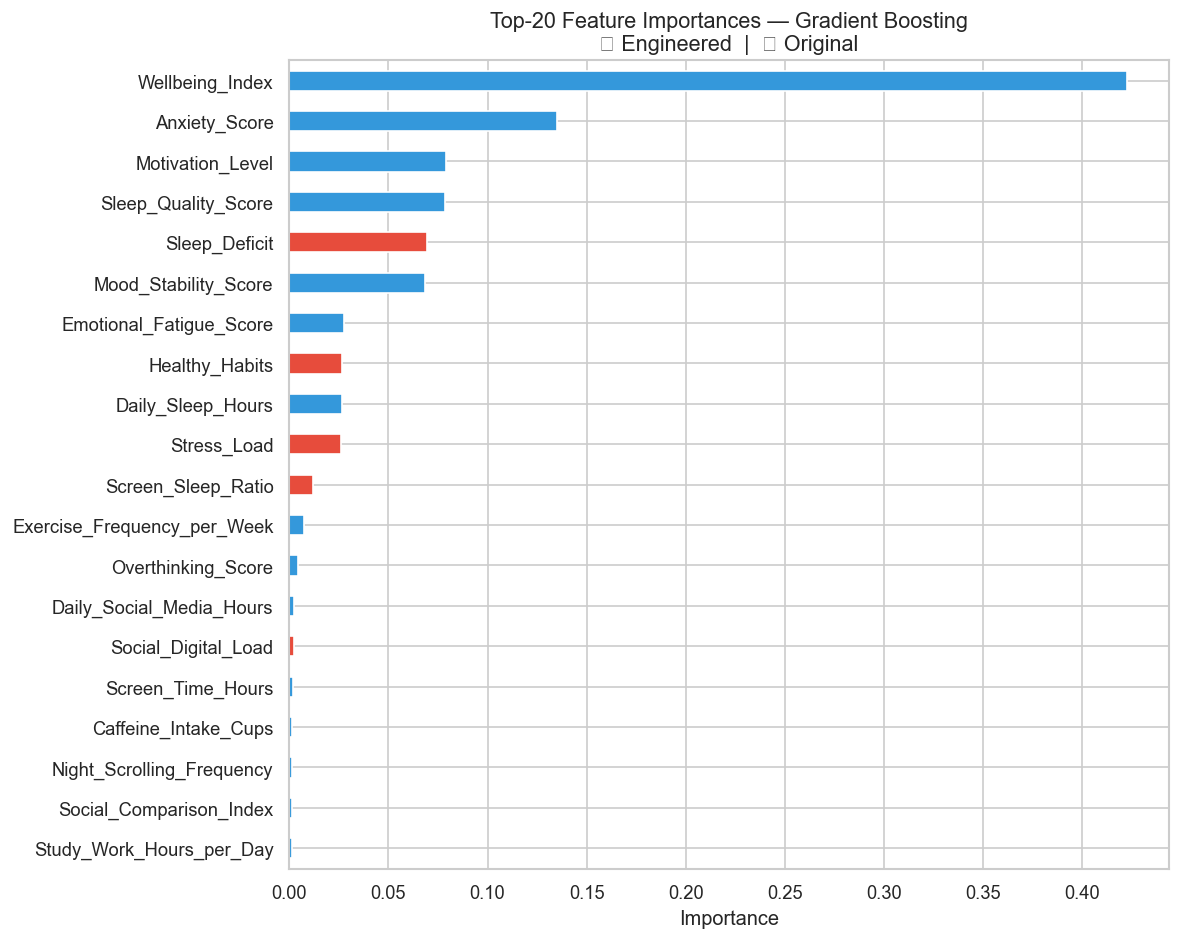


Top-10 features:
Wellbeing_Index           0.42
Anxiety_Score             0.14
Motivation_Level          0.08
Sleep_Quality_Score       0.08
Sleep_Deficit             0.07
Mood_Stability_Score      0.07
Emotional_Fatigue_Score   0.03
Healthy_Habits            0.03
Daily_Sleep_Hours         0.03
Stress_Load               0.03


In [23]:
import re

# ── Reconstruct feature names after ColumnTransformer ────────────────────────
ohe_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(CAT_COLS)
all_feature_names = np.concatenate([NUM_COLS, ohe_feature_names])

# ── Extract importances from tree-based model ─────────────────────────────────
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
else:
    # Fallback: use a Random Forest if tuned model has no feature_importances_
    fallback = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    fallback.fit(X_train_t, y_train)
    importances = fallback.feature_importances_

feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
top20 = feat_imp.head(20)

# Highlight engineered features
ENG_FEATURES = {"Stress_Load", "Sleep_Deficit", "Screen_Sleep_Ratio",
                "Social_Digital_Load", "Healthy_Habits"}
colors = ["#e74c3c" if f in ENG_FEATURES else "#3498db" for f in top20.index]

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot(kind="barh", color=list(reversed(colors)), edgecolor="white", ax=ax)
ax.set_title(f"Top-20 Feature Importances — {tune_name}\n"
             "🔴 Engineered  |  🔵 Original", fontsize=13)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop-10 features:")
print(top20.head(10).round(4).to_string())

## 12 — Summary

In [24]:
# ── Complete model leaderboard ────────────────────────────────────────────────
summary_rows = []
for name, res in results.items():
    summary_rows.append({
        "Model": name,
        "Accuracy": round(res["Accuracy"], 4),
        "F1 (weighted)": round(res["F1 (weighted)"], 4),
        "Tuned": name == tune_name,
    })

# Add tuned version
summary_rows.append({
    "Model": f"{tune_name} (tuned)",
    "Accuracy": round(acc_tuned, 4),
    "F1 (weighted)": round(f1_tuned, 4),
    "Tuned": True,
})

summary_df = (pd.DataFrame(summary_rows)
              .sort_values("F1 (weighted)", ascending=False)
              .reset_index(drop=True))

print("=" * 60)
print("         FINAL MODEL LEADERBOARD")
print("=" * 60)
display(summary_df.style
        .highlight_max(subset=["Accuracy", "F1 (weighted)"], color="lightgreen")
        .set_caption("Green = best score in column")
        .format({"Accuracy": "{:.4f}", "F1 (weighted)": "{:.4f}"}))

         FINAL MODEL LEADERBOARD


,Model,Accuracy,F1 (weighted),Tuned
0,Gradient Boosting,0.9975,0.9975,True
1,Random Forest,0.9955,0.9953,False
2,Gradient Boosting (tuned),0.9950,0.9947,True
3,XGBoost,0.9945,0.9944,False
4,LightGBM,0.9940,0.9939,False
5,Logistic Regression,0.9925,0.9923,False
6,Extra Trees,0.9775,0.9764,False


In [25]:
# ── Save best model + preprocessor ───────────────────────────────────────────
import joblib

joblib.dump({"preprocessor": preprocessor,
             "model": best_model,
             "label_encoder": le_target}, "burnout_best_model.pkl")
print("Model saved to burnout_best_model.pkl ✓")

# ── Key takeaways ─────────────────────────────────────────────────────────────
print(f"""
╔══════════════════════════════════════════════════════════════╗
║           GEN Z BURNOUT RISK — KEY TAKEAWAYS                ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset:     {df.shape[0]:,} rows × {df.shape[1]} columns                    ║
║  Target:      Burnout_Risk (Low / Medium / High)             ║
║  Best model:  {tune_name:<45} ║
║  Test Acc:    {acc_tuned:.4f}                                          ║
║  Test F1:     {f1_tuned:.4f}  (weighted)                              ║
╠══════════════════════════════════════════════════════════════╣
║  Top engineered features by importance:                      ║
║    • Stress_Load  (Anxiety + Overthinking + Fatigue)         ║
║    • Sleep_Deficit / Screen_Sleep_Ratio                      ║
║    • Social_Digital_Load / Healthy_Habits                    ║
╚══════════════════════════════════════════════════════════════╝
""")

Model saved to burnout_best_model.pkl ✓

╔══════════════════════════════════════════════════════════════╗
║           GEN Z BURNOUT RISK — KEY TAKEAWAYS                ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset:     10,000 rows × 22 columns                    ║
║  Target:      Burnout_Risk (Low / Medium / High)             ║
║  Best model:  Gradient Boosting                             ║
║  Test Acc:    0.9950                                          ║
║  Test F1:     0.9947  (weighted)                              ║
╠══════════════════════════════════════════════════════════════╣
║  Top engineered features by importance:                      ║
║    • Stress_Load  (Anxiety + Overthinking + Fatigue)         ║
║    • Sleep_Deficit / Screen_Sleep_Ratio                      ║
║    • Social_Digital_Load / Healthy_Habits                    ║
╚══════════════════════════════════════════════════════════════╝

